# Spotify Lab: Vectors, Inner Products, and Similar Songs

**Name(s):** Corrine Bresky

You are a new data engineer at Spotify.

When a listener asks for songs with similar content, we want to query the library of music and select appropriate recommendations. 

Every song is represented as a vector, and we are using a **vector database**: Each song is encoded as a vector of word counts. So if "love" appears 12 times in the song, the "love" coordinate is $x_{\text{love}}=12$. If Metallica writes songs about topics that are more similar to Black Sabbath than to Josh Groban, then the vector representations of their songs will have more similar profiles, and we should suggest Black Sabbath over Josh Groban. This approach is fundamental to technologies like LLMs or facial recognition, which store documents and faces as vectors and conducts fast look-ups using the kinds of math we'll look at in this lab.

The main data, `song_vectors.csv.gz`, include:

- `track_id`, `song_id`, `artist_id`: Internal unique track identifiers
- `artist_name`, `song_title`, `release`: Artist, song, album
- `release_year`, `duration`: `
- `artist_familiarity`, `artist_hotttnesss`: Measures of ubiquity, popularity
- `genre`, `top_tags`: Information about the song type
- `n_words`, `nnz_words`, `l2_norm`: Number of total words in the song, number of non-zero word coordinates (i.e. number of unique words), and the word counts squared/summed/square-rooted.
- `is_test`: Train-test split identification
- 800 columns of word counts

The `top_40_songs_by_genre.csv` file contains the top 40 songs by genre -- rock, metal, pop, punk, country, r&b/soul, folk, hip hop, electronic, blues, jazz, reggae, latin, classical -- by "hotttness". We'll use these songs to benchmark.

The `vocabulary.csv` file includes the 800 words that form the vector space in which the songs are modeled.

Each song becomes a vector of lyric-word counts, and then we use vector operations to quantify "similarity".

The big goal of this lab is simple:

**Vectors and inner products and vector length are the core tools of modern retrieval systems.**

## Lab Overview and Submission

**Add your name to the top of this notebook and name anyone you worked closely with.** Add this notebook to a personal GitHub repository and submit the repository link in Canvas. Every group member should be able to explain the code and conclusions in the submitted work.

The goal of this lab is to use vectors and inner products to build, inspect, and critique a small song-recommendation system. You will represent songs using lyric word counts, compare several measures of similarity, and decide which measure produces the most useful recommendations.

### Part 1: Basic Similarity Measures

Complete the steps in this notebook. For each method, run the code, inspect the rankings and plots, and respond to the yellow prompts in your own words. Explain what the score measures, how the top matches change, and whether the method is rewarding genuine lyric similarity, song length, or some other pattern.

### Part 2: Recommendation Logic

Use cosine similarity to build the final 10-song recommendation list after excluding the query song itself. Evaluate that choice against the dot-product ranking. Identify at least two specific songs that illustrate an important difference between the rankings, and explain what that difference reveals about the two scoring rules.

### Short Written Explanation

At the end of this notebook, write a 2-4 paragraph response. State which similarity measure you would recommend Spotify use for this lyric-only prototype, justify your choice with results from your analysis, and discuss at least two concrete examples from the rankings. Briefly note one important limitation of lyric word counts alone and name information that could make a real recommendation system better.

Your completed submission should include this notebook with all code executed, outputs visible, and written responses included.

## Setup

We will use:

- `./data/song_vectors.csv.gz`: one row per song
- `./data/vocabulary.csv`: the word columns used in the song vectors

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


songs = pd.read_csv( "./data/song_vectors.csv.gz" )
vocab = pd.read_csv( "./data/vocabulary.csv" )
top_40 = pd.read_csv("./data/top_40_songs_by_genre.csv")

word_cols = vocab["word"].tolist() # Song count matrix
meta_cols = songs.columns.drop(word_cols).tolist() # Information about tracks

print('Number of songs, number of words:', songs.shape)
print( 'Song metadata fields:', meta_cols[:8])

Number of songs, number of words: (8000, 816)
Song metadata fields: ['track_id', 'song_id', 'artist_id', 'artist_name', 'song_title', 'release', 'release_year', 'duration']


In [3]:
songs[meta_cols].head()

,track_id,song_id,artist_id,artist_name,song_title,release,release_year,duration,artist_familiarity,artist_hotttnesss,genre,top_tags,n_words,nnz_words,l2_norm,is_test
0,TRAAPIV128F1493132,SOJHKYL12A6D4FA0AC,AR56P361187B9AC4DB,Gary Moore,What Are We Here For,Dark Days In Paradise,1997,345.93914,0.761362,0.467111,blues,blues; classic rock; rock; hard rock; blues rock,218,80,37.376463,0
1,TRAAWOR128F92DF3C8,SOBJYXZ12A8AE45FF1,ARY80281187FB3E380,Sandi Thom,Wounded Hearts,The Pink & The Lily,2008,205.21751,0.655359,0.405031,blues,blues,287,103,39.698866,0
2,TRABNZS128F932C6E8,SOCOZZE12A813568F7,AROWOZ41187FB5B535,G. Love & Special Sauce,Willow Tree,Yeah_ It's That Easy,1997,206.57587,0.717235,0.548694,blues,blues; chill; alternative; rock; jazz,211,64,33.090784,0
3,TRABOIH128F9300B06,SOHYOTB12AF72AA1D7,AR94ZOI1187FB46BDA,Willie Dixon,That's My Baby,Very Best Of The Blues,1989,208.90077,0.579533,0.429834,blues,delta blues; BLUEZZZ; blues; freedom; Willie D...,164,76,27.477263,0
4,TRABYAR128F931B1A4,SOVKUOE12A58A8066E,AR7BMMV1187FB5B2D7,Robben Ford,Something For The Pain,Blue Moon,2002,298.37016,0.604820,0.383877,blues,blues; Robben Ford; vinnie colaiuta; jimmy earl,187,75,27.604347,0


## Part 1: Similarity Measures for Song Vectors

The word-count columns are coordinates. That means each song is a vector in a high-dimensional space.

We will work with the song-by-word matrix $X$, where each row is one song vector.

In [4]:
X = songs[word_cols].to_numpy(dtype=float)

query_idx = 0 # Let's query the first song
query = X[query_idx]

print( 'Track metadata: \n')
print(songs.loc[query_idx, meta_cols])

print( 'Track word counts: \n')
print( query )

Track metadata: 

track_id                                            TRAAPIV128F1493132
song_id                                             SOJHKYL12A6D4FA0AC
artist_id                                           AR56P361187B9AC4DB
artist_name                                                 Gary Moore
song_title                                        What Are We Here For
release                                          Dark Days In Paradise
release_year                                                      1997
duration                                                     345.93914
artist_familiarity                                            0.761362
artist_hotttnesss                                             0.467111
genre                                                            blues
top_tags              blues; classic rock; rock; hard rock; blues rock
n_words                                                            218
nnz_words                                                  

In [5]:
# Let's see the counts for nonzero words

nonzero = np.flatnonzero(query)

pd.DataFrame({
    "word": np.array(word_cols)[nonzero],
    "count": query[nonzero].astype(int),
}).sort_values("count", ascending=False).head(15)

,word,count
62,we,27
4,are,10
17,for,9
37,of,7
26,it,6
63,what,6
21,here,6
20,have,6
41,our,5
54,through,5


## Step 1: Dot Product

The dot product is our first similarity score:

$$
x \cdot y = \sum_{j=1}^m x_j y_j
$$

It gets large when two songs align count mass on the same words. 

It also tends to go up for longer songs or songs with larger total counts, which is a choice we'll have to think about.

In [6]:
# Compute the dot product between every song vector and the query vector.
dot_scores = X @ query

dot_results = songs[meta_cols].copy()
dot_results["dot"] = dot_scores
dot_results.sort_values("dot", ascending=False).head(10)

,track_id,song_id,artist_id,artist_name,song_title,release,release_year,duration,artist_familiarity,artist_hotttnesss,genre,top_tags,n_words,nnz_words,l2_norm,is_test,dot
1582,TRFSCLD12903CD213F,SOENGNL12AB018E1BD,AR4L4WQ1187FB51996,The Prodigy,We Gonna Rock,What Evil Lurks,1991,282.30485,0.638614,0.601436,electronic,Rave; big beat; jungle; electronic; techno,312,10,141.703917,0,2136.0
6290,TRFUJVJ128F426F2A2,SOONCPO12AF72A1986,AR8W8P31187B9A4063,Lauryn Hill,Interlude 5,MTV Unplugged No. 2.0,2002,734.48444,0.697206,0.580125,r&b/soul,ms hill; the realness; The Truth; true; rnb,1903,409,215.044182,0,2115.0
5601,TRCETEN128F42AD6D0,SOXSRBF12D021B1340,AR4KTMS1187B9B4873,Bowling For Soup,Here We Go,Goes To The Movies,2004,188.36853,0.790406,0.561934,punk,pop punk; The Good Stuff; Bowling For Soup; pr...,374,92,98.863542,0,1939.0
1930,TRWAMJL128F92D124B,SOUSJHY12A8C1457F0,ARQ85IK11C8A415C6A,Ladyhawke,Crazy World,Ladyhawke,2008,214.93506,0.692569,0.554471,electronic,electropop; indie; female vocalists; electroni...,340,58,74.229374,0,1680.0
6997,TRLDRZN128F4288F63,SOBLSVV12A8C13E4F8,ARLUAK21187B9B785A,Ziggy Marley And The Melody Makers,We Propose,Conscious Party,0,274.46812,0.750480,0.538491,reggae,reggae; marijuana; Reg-i-die,297,97,58.180753,0,1656.0
3053,TRTCOWO128F930C444,SONWWDY12A6D4F7FB1,ARIHE7O1187FB47DED,The Streets,Weak Become Heroes,Summer Sessions,0,494.54975,0.772909,0.527872,hip hop,british; Hip-Hop; garage; 00s; hip hop,754,262,96.337947,0,1654.0
2971,TRPDBLM128E0792367,SOZRPOY12A8C1455F5,ARTDQRC1187FB4EFD4,Black Eyed Peas,Communication,Behind The Front,1998,344.00608,0.845602,1.005942,hip hop,Hip-Hop; funk; dance; communication; heisse sc...,592,173,80.068720,0,1615.0
2874,TRKRVKD128F9327008,SOXKVEZ12AB01821F5,ARX94AN1187FB4B54B,Hollywood Undead,Undead,Desperate Measures,2008,288.07791,0.703476,0.576626,hip hop,rapcore; hollywood undead; rap metal; rock; un...,831,222,97.082439,0,1476.0
0,TRAAPIV128F1493132,SOJHKYL12A6D4FA0AC,AR56P361187B9AC4DB,Gary Moore,What Are We Here For,Dark Days In Paradise,1997,345.93914,0.761362,0.467111,blues,blues; classic rock; rock; hard rock; blues rock,218,80,37.376463,0,1397.0
5840,TRMGOLR128F933A7DB,SOYDERO12A6D4F72BC,ARZWK2R1187B98F09F,Rise Against,Survive,The Sufferer & The Witness,2006,221.46567,0.847082,0.625080,punk,punk rock; melodic hardcore; punk; rock; Rise ...,324,85,56.169387,0,1383.0


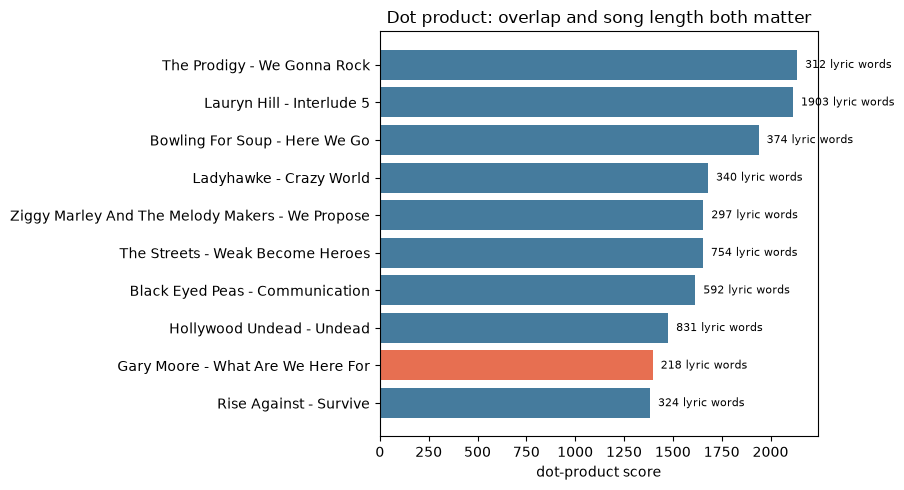

In [7]:
# Visual check: long songs can receive larger dot products.
top_dot = dot_results.sort_values("dot", ascending=False).head(10).copy()
top_dot["label"] = (
    top_dot["artist_name"].fillna("") + " - " + top_dot["song_title"].fillna("")
)
colors = ["#e76f51" if index == query_idx else "#457b9d" for index in top_dot.index]
plt.figure(figsize=(9, 5))
plt.barh(top_dot["label"], top_dot["dot"], color=colors)
for position, words in enumerate(top_dot["n_words"]):
    plt.text(top_dot["dot"].iloc[position], position, f"  {words:.0f} lyric words", va="center", fontsize=8)
plt.gca().invert_yaxis()
plt.xlabel("dot-product score")
plt.title("Dot product: overlap and song length both matter")
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-warning">

Look at the top matches. Do they seem similar because they use similar words, because they are genuinely similar songs, or because the dot product is partly rewarding song size?

Adapt the above code chunks to find the top three **non-self** matches for all of the Top 40 songs by genre using the raw inner product. Before sorting, set the query song's score to `-np.inf`. Save your results as additional columns in "./data/top_40_songs_by_genre_results.csv".

</div>

- The top matches do not seem like they are similar to the query song because they use similar words and/or are similar songs. It looks more like the dot product is partially rewarding songs that are longer/bigger in size. For example, you can see Lauryn Hill's Interlude 5 has 1903 words and is at the top, though it doesn't necessarily seem to be an incredibly similar song to Gary Moore's What Are We Here For, which has only 218 words.

In [8]:
top_40_calcs = top_40.copy()
top1, top2, top3 = [], [], []

for track_id in top_40["track_id"]: #using track_id to make sure i get the right row for each top 40 song
    query_idx = songs.index[songs["track_id"] == track_id][0] #find the index of the track in the songs dataframe
    query = X[query_idx]
    raw_dot = pd.Series(X @ query) #make numpy array into a pandas series so i can use sort_values
    raw_dot[query_idx] = -np.inf #avoids self matching

    top_matches = raw_dot.sort_values(ascending=False).head(3) #keep top 3 matches

    top1.append(songs.loc[top_matches.index[0], "song_title"]) #get the song title of first match and append to list
    top2.append(songs.loc[top_matches.index[1], "song_title"])
    top3.append(songs.loc[top_matches.index[2], "song_title"])

top_40_calcs["top1_raw_dot"] = top1 #adding new cols
top_40_calcs["top2_raw_dot"] = top2
top_40_calcs["top3_raw_dot"] = top3

top_40_calcs.to_csv("./data/top_40_songs_by_genre_results.csv", index=False)

top_40_calcs.head()


,track_id,song_id,artist_id,artist_name,song_title,genre,top1_raw_dot,top2_raw_dot,top3_raw_dot
0,TRVYEUW128F148C08D,SOFCCWD12AF72A6BC0,ARXPPEY1187FB51DF4,Michael Jackson,All The Things You Are,blues,Interlude 5,I'm A Winner (Amended Album Version),Hot N Cold (Innerpartysystem Main)
1,TRCXKPC128F92FD04C,SOEFNXT12AB017E829,ARZENOX1187B98A645,John Mayer,Vultures,blues,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,Interlude 5,I Mean (I Don't Mean It)
2,TRMMALW128F92FD049,SOVUCRS12A58A7D207,ARZENOX1187B98A645,John Mayer,Out Of My Mind,blues,Interlude 5,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,I'm A Winner (Amended Album Version)
3,TRJWAJC128F9327C4F,SORMDVX12AB01816AA,ARLMXEA1187B9A7D04,R. Kelly,Hump Bounce,blues,Interlude 5,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,I Want You
4,TRPEBTH128F9327C4D,SOYTJAC12AF729F49D,ARLMXEA1187B9A7D04,R. Kelly,Intro - The Sermon,blues,Interlude 5,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,I'm A Winner (Amended Album Version)


## Step 2: Centering and Covariance

Now we subtract each vector's own mean. This changes the question from "Do these songs use many of the same words?" to something closer to "Do these songs rise above and below their own average on the same words?"

In [9]:
query_centered = query - query.mean()
X_centered = X - X.mean(axis=1, keepdims=True)

centered_dot_scores = X_centered @ query_centered
covariance_scores = centered_dot_scores / X.shape[1]

cov_results = songs[meta_cols].copy()
cov_results["centered_dot"] = centered_dot_scores
cov_results["covariance"] = covariance_scores
cov_results.sort_values("covariance", ascending=False).head(10)

,track_id,song_id,artist_id,artist_name,song_title,release,release_year,duration,artist_familiarity,artist_hotttnesss,genre,top_tags,n_words,nnz_words,l2_norm,is_test,centered_dot,covariance
6290,TRFUJVJ128F426F2A2,SOONCPO12AF72A1986,AR8W8P31187B9A4063,Lauryn Hill,Interlude 5,MTV Unplugged No. 2.0,2002,734.48444,0.697206,0.580125,r&b/soul,ms hill; the realness; The Truth; true; rnb,1903,409,215.044182,0,4783.12000,5.978900
2691,TRDPGXU128F9339C2A,SOELYON12AB01876A3,ARLHO5Z1187FB4C861,Beastie Boys,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,Paul's Boutique (20th Anniversary Remastered E...,0,105.56036,0.853125,0.591628,hip hop,hip hop; leapsandbounds CDCollection,1746,505,153.652205,0,4767.60375,5.959505
2659,TRCHZXW128E079288A,SOMEJDK12D0219BB71,ARTH9041187FB43E1F,Eminem,8 Mile,8 Mile,2002,359.39220,0.886184,0.852677,hip hop,rap; Hip-Hop; Eminem; Soundtrack; hip hop,1141,328,132.992481,0,4094.49625,5.118120
3029,TRRSNPA128F148C45E,SOIUOEW12A67021D3D,AR8RXRI1187FB4104B,The Roots,Mellow My Man,From The Ground Up,0,288.31302,0.862795,0.600282,hip hop,Hip-Hop; jazzy; the roots; rap; hip hop,886,270,117.358425,0,3734.87625,4.668595
2763,TRGLNKG128F9307689,SOFVLYU12AB017F502,ARTH9041187FB43E1F,Eminem,My Darling,Relapse [Deluxe],2009,320.49587,0.871011,0.879237,hip hop,rap; detroit; Hip-Hop; Horrorcore; MOONH8SUN,1055,293,140.089257,0,3704.24125,4.630302
5245,TRLTYLK128F92FE6FF,SOWVIEO12AB0182D10,AR03BDP1187FB5B324,Britney Spears,Radar,Radar,2007,353.33179,0.947328,0.607257,pop,pop; dance; Britney Spears; female vocalists; ...,500,96,116.614750,0,3635.32375,4.544155
3125,TRWSYHO128F4282346,SOKHOQG12A8C13EBF2,ARSE5NP1187B9B98AB,Twista,I'm A Winner (Amended Album Version),The Day After,2005,260.23138,0.889614,0.593808,hip hop,rap; Hip-Hop; winner in bed twista,1253,166,218.622963,0,3594.83250,4.493541
2815,TRISBQQ128F93217A2,SOSKAYL12AB01884DE,ARPXABO1187FB4D15F,2Pac,Strictly 4 My N.I.G.G.A.Z.,Strictly 4 My N.I.G.G.A.Z.,0,355.47383,0.873187,0.517256,hip hop,Hip-Hop; hardcore rap; west coast hip-hop; lea...,921,288,104.316825,0,3565.21250,4.456516
2627,TRBEBJO128C719646B,SORXHBR12AF72A5DA5,ARCBD0U1187FB466EF,Nelly,Splurge,Nellyville,2002,309.49832,0.912369,0.787995,hip hop,Hip-Hop; rap; hip hop; rnb; 00s,911,225,131.289756,0,3550.71125,4.438389
6492,TROIJDA128F9341E70,SOCUXGX12A8C13B78C,ARLMXEA1187B9A7D04,R. Kelly,I Mean (I Don't Mean It),TP-2.com,2000,205.00853,0.811092,0.783843,r&b/soul,soul; rnb; english lyrics; SDZ,701,190,135.443715,0,3531.92375,4.414905


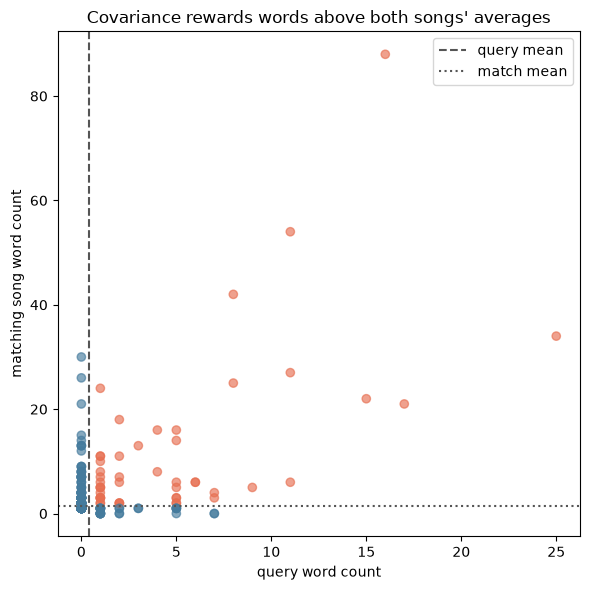

In [10]:
# Visual check: centering moves each song's average word count to zero.
comparison_idx = np.argsort(covariance_scores)[-2]
comparison = X[comparison_idx]
used_words = (query > 0) | (comparison > 0)
both_above_average = (query > query.mean()) & (comparison > comparison.mean())
plt.figure(figsize=(6, 6))
plt.scatter(query[used_words], comparison[used_words],
            c=np.where(both_above_average[used_words], "#e76f51", "#457b9d"), alpha=0.65)
plt.axvline(query.mean(), color="#555555", linestyle="--", label="query mean")
plt.axhline(comparison.mean(), color="#555555", linestyle=":", label="match mean")
plt.xlabel("query word count")
plt.ylabel("matching song word count")
plt.title("Covariance rewards words above both songs' averages")
plt.legend()
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-warning">

Compare the rankings from dot product and covariance. What changed? Why does subtracting the mean change the notion of similarity?

Adapt the above code chunks to find the top three **non-self** matches for all of the Top 40 songs by genre using the centered inner product. Before sorting, set the query song's score to `-np.inf`. Save your results as additional columns in "./data/top_40_songs_by_genre_results.csv".

</div>

- Covariance, because it subtracts the mean, looks at how similar the songs are in terms of how they use words relative to their own averages. It is still influenced by vector length/magnitude, but it seems like it is much less influenced by this compared to the raw dot product calculations. So, the pattern of word usage becomes more important rather than just total number of words. It is interesting to see that Lauryn Hill's Interlude 5 ranks so highly under both calculations. My guess is that because the word count for that song is so large, even after accounting for each song's average word count, the effect of the song length is not removed completely with covariance.

In [11]:
top1_centered_dot, top2_centered_dot, top3_centered_dot = [], [], []

for track_id in top_40["track_id"]: #using track_id to make sure i get the right row for each top 40 song
    query_idx = songs.index[songs["track_id"] == track_id][0]
    query = X_centered[query_idx]
    centered_dot = pd.Series(X_centered @ query) #make numpy array into a pandas series so i can use sort_values
    centered_dot[query_idx] = -np.inf #avoids self matching

    top_matches = centered_dot.sort_values(ascending=False).head(3) #keep top 3 matches

    top1_centered_dot.append(songs.loc[top_matches.index[0], "song_title"]) #get the song title of first match and append to list
    top2_centered_dot.append(songs.loc[top_matches.index[1], "song_title"])
    top3_centered_dot.append(songs.loc[top_matches.index[2], "song_title"])

top_40_calcs["top1_centered_dot"] = top1_centered_dot #adding new cols
top_40_calcs["top2_centered_dot"] = top2_centered_dot
top_40_calcs["top3_centered_dot"] = top3_centered_dot

top_40_calcs.to_csv("./data/top_40_songs_by_genre_results.csv", index=False)

top_40_calcs.head()

,track_id,song_id,artist_id,artist_name,song_title,genre,top1_raw_dot,top2_raw_dot,top3_raw_dot,top1_centered_dot,top2_centered_dot,top3_centered_dot
0,TRVYEUW128F148C08D,SOFCCWD12AF72A6BC0,ARXPPEY1187FB51DF4,Michael Jackson,All The Things You Are,blues,Interlude 5,I'm A Winner (Amended Album Version),Hot N Cold (Innerpartysystem Main),Interlude 5,I'm A Winner (Amended Album Version),Hot N Cold (Innerpartysystem Main)
1,TRCXKPC128F92FD04C,SOEFNXT12AB017E829,ARZENOX1187B98A645,John Mayer,Vultures,blues,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,Interlude 5,I Mean (I Don't Mean It),I Mean (I Don't Mean It),B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,8 Mile
2,TRMMALW128F92FD049,SOVUCRS12A58A7D207,ARZENOX1187B98A645,John Mayer,Out Of My Mind,blues,Interlude 5,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,I'm A Winner (Amended Album Version),Interlude 5,I'm A Winner (Amended Album Version),B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...
3,TRJWAJC128F9327C4F,SORMDVX12AB01816AA,ARLMXEA1187B9A7D04,R. Kelly,Hump Bounce,blues,Interlude 5,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,I Want You,Interlude 5,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,I Want You
4,TRPEBTH128F9327C4D,SOYTJAC12AF729F49D,ARLMXEA1187B9A7D04,R. Kelly,Intro - The Sermon,blues,Interlude 5,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,I'm A Winner (Amended Album Version),Interlude 5,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,I'm A Winner (Amended Album Version)


## Step 3: Correlation

Correlation takes covariance and rescales by each vector's standard deviation. That means we now compare shared pattern after accounting for both average level and spread.

In [12]:
query_std = query.std()
X_std = X.std(axis=1)

denom = X_std * query_std
corr_scores = np.divide(
    covariance_scores,
    denom,
    out=np.zeros_like(covariance_scores),
    where=denom != 0,
)

corr_results = songs[meta_cols].copy()
corr_results["correlation"] = corr_scores
corr_results.sort_values("correlation", ascending=False).head(10)

,track_id,song_id,artist_id,artist_name,song_title,release,release_year,duration,artist_familiarity,artist_hotttnesss,genre,top_tags,n_words,nnz_words,l2_norm,is_test,correlation
7795,TRRKJGZ128F148128F,SOAQCXS12D02191FC1,ART1UFU1187FB4C9B6,Hawk Nelson,Something On My Mind,Smile_ It's The End Of The World,2006,259.18649,0.738436,0.621970,rock,cross2life; alternative; favorites; christian;...,345,92,51.913389,0,1.000000
7779,TRQXNHC12903CD80BA,SOFKHCP12A8AE460AF,ARV4GYZ1187B9B8171,Violent Femmes,Add It Up,Permanent Record: The Very Best Of The Violent...,1983,284.34240,0.699073,0.522720,rock,alternative; 80s; rock; punk; indie,479,145,60.745370,0,0.694141
2815,TRISBQQ128F93217A2,SOSKAYL12AB01884DE,ARPXABO1187FB4D15F,2Pac,Strictly 4 My N.I.G.G.A.Z.,Strictly 4 My N.I.G.G.A.Z.,0,355.47383,0.873187,0.517256,hip hop,Hip-Hop; hardcore rap; west coast hip-hop; lea...,921,288,104.316825,0,0.692422
7358,TRBCRNY128F931D755,SOZHKRD12AB0185D84,ARKXXO11187FB4D9D9,Bad Cash Quartet,Valentine,Midnight Prayer,2003,175.62077,0.560999,0.399430,rock,indie; swedish; indie pop; indie rock; vocal,157,68,24.879711,0,0.682567
3129,TRWUNDW128F147093F,SOFZLVC12A6D4F9068,ARNHMFD1187FB3B3F6,LL Cool J,I Can't Live Without My Radio,Radio,1985,331.88526,0.749218,0.544322,hip hop,Hip-Hop; rap; 80s; LL Cool J; hip hop,745,248,81.829090,0,0.681100
2809,TRILLIR128F429E5D7,SOGGIPC12A8C142CD5,AR6F6I21187FB5A3AA,Aesop Rock,Battery,Labor Days,2001,307.04281,0.834539,0.477311,hip hop,Hip-Hop; underground hip-hop; rap; hip hop; De...,617,294,50.547008,0,0.680866
3112,TRWFXWM128F148D2D1,SORSMQE12A58A7A5FE,ARSQSCB1187B9912A0,Warren G,We Brings Heat,Take A Look Over Your Shoulder (Reality),1997,226.92526,0.718017,0.511683,hip hop,chillout; classic; hip hop; cool; Hip-Hop,548,238,50.517324,0,0.677367
3065,TRTMQWK128F4241384,SOIPJHX12A8C1324A3,ARSUQ9F1187B990561,Kottonmouth Kings,Bump,Greatest Highs,1998,232.51546,0.680868,0.563168,hip hop,Hip-Hop; stoned; BUMP; rapcore; kmk,795,259,74.276510,0,0.665229
2841,TRJPNAE128F425FAFB,SOZVCKM12A8C138484,ARRQWQW1187FB49844,King Tee,Act A Fool,Act A Fool,1988,258.82077,0.495739,0.372392,hip hop,Hip-Hop; rap; hip hop; West Coast Rap; west co...,624,251,66.730802,0,0.663739
7974,TRZCHKB128F92CB740,SOFCVMN12A8C141F62,AR4RBOB1187B9AC209,Anastacia,Club Megamix,Pieces Of A Dream,0,708.72771,0.583809,0.323554,rock,Slow Rock; pop; dance; party; female vocalist,749,201,98.020406,0,0.663071


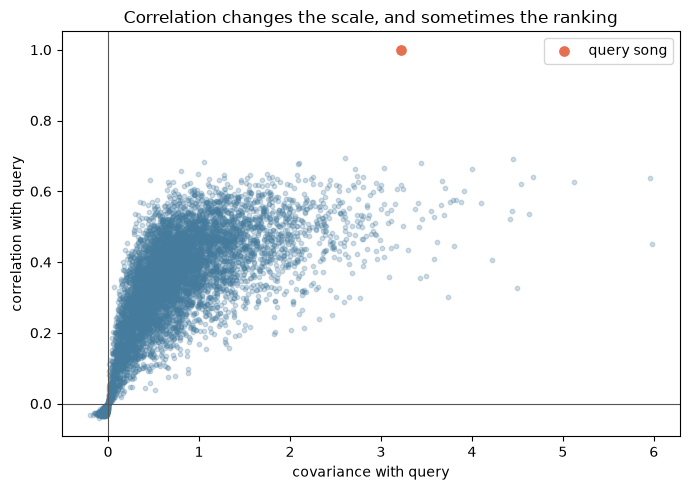

In [13]:
# Visual check: correlation rescales covariance by each song's spread.
plt.figure(figsize=(7, 5))
plt.scatter(covariance_scores, corr_scores, s=10, alpha=0.25, color="#457b9d")
plt.axhline(0, color="#555555", linewidth=0.8)
plt.axvline(0, color="#555555", linewidth=0.8)
plt.scatter(covariance_scores[query_idx], corr_scores[query_idx], color="#e76f51", s=45, label="query song")
plt.xlabel("covariance with query")
plt.ylabel("correlation with query")
plt.title("Correlation changes the scale, and sometimes the ranking")
plt.legend()
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-warning">

Correlation and covariance are related, but not identical. What kind of song might move up in the ranking after standardization? What kind might move down?

Adapt the above code chunks to find the top three **non-self** matches for all of the Top 40 songs by genre using the correlation. Before sorting, set the query song's score to `-np.inf`. Save your results as additional columns in "./data/top_40_songs_by_genre_results.csv".

</div>

- The kind of song that might move up in the ranking after standardization would be one that is a little shorter in length but follows a similar word usage pattern to the song being queried. On the other hand, a song that might move down after standardization could be a long song with a large word count; for example, Lauryn Hill's Interlude 5 has a large word count and still ranked highly using covariance, so standardization seemed to reduce some of the advantage it gets from its size and cause it to move down in the rankings. It doesn't appear in the top rankings based on correlation.

In [ ]:
top1_correlation, top2_correlation, top3_correlation = [], [], []

for track_id in top_40["track_id"]: #using track_id to make sure i get the right row for each top 40 song
    query_idx = songs.index[songs["track_id"] == track_id][0]
    query = X[query_idx]
    query_centered = query - query.mean()
    
    centered_dot = X_centered @ query_centered
    covariance = centered_dot / X.shape[1]
    
    correlation = covariance / (X.std(axis=1) * query.std()) #following code from above example
    
    correlation = pd.Series(correlation) #make numpy array into a pandas series so i can use sort_values
    correlation[query_idx] = -np.inf #avoids self matching

    top_matches = correlation.sort_values(ascending=False).head(3) #keep top 3 matches

    top1_correlation.append(songs.loc[top_matches.index[0], "song_title"]) #get the song title of first match and append to list
    top2_correlation.append(songs.loc[top_matches.index[1], "song_title"])
    top3_correlation.append(songs.loc[top_matches.index[2], "song_title"])

top_40_calcs["top1_correlation"] = top1_correlation #adding new cols
top_40_calcs["top2_correlation"] = top2_correlation
top_40_calcs["top3_correlation"] = top3_correlation

top_40_calcs.to_csv("./data/top_40_songs_by_genre_results.csv", index=False)

top_40_calcs.head()

,track_id,song_id,artist_id,artist_name,song_title,genre,top1_raw_dot,top2_raw_dot,top3_raw_dot,top1_centered_dot,top2_centered_dot,top3_centered_dot,top1_correlation,top2_correlation,top3_correlation
0,TRVYEUW128F148C08D,SOFCCWD12AF72A6BC0,ARXPPEY1187FB51DF4,Michael Jackson,All The Things You Are,blues,Interlude 5,I'm A Winner (Amended Album Version),Hot N Cold (Innerpartysystem Main),Interlude 5,I'm A Winner (Amended Album Version),Hot N Cold (Innerpartysystem Main),You're All The World To Me,You're The Top,You're A Soldier
1,TRCXKPC128F92FD04C,SOEFNXT12AB017E829,ARZENOX1187B98A645,John Mayer,Vultures,blues,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,Interlude 5,I Mean (I Don't Mean It),I Mean (I Don't Mean It),B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,8 Mile,Plastic World,The Ups And Downs,Keep Moving
2,TRMMALW128F92FD049,SOVUCRS12A58A7D207,ARZENOX1187B98A645,John Mayer,Out Of My Mind,blues,Interlude 5,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,I'm A Winner (Amended Album Version),Interlude 5,I'm A Winner (Amended Album Version),B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,Preacher On A Sunday Morning,Ready For The Weekend,Beyond Salvation
3,TRJWAJC128F9327C4F,SORMDVX12AB01816AA,ARLMXEA1187B9A7D04,R. Kelly,Hump Bounce,blues,Interlude 5,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,I Want You,Interlude 5,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,I Want You,All I Do,Overjoyed,Day And Night
4,TRPEBTH128F9327C4D,SOYTJAC12AF729F49D,ARLMXEA1187B9A7D04,R. Kelly,Intro - The Sermon,blues,Interlude 5,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,I'm A Winner (Amended Album Version),Interlude 5,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,I'm A Winner (Amended Album Version),Hook,I Don't Want To Talk About It,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...


## Step 4: Cosine Similarity

Cosine similarity compares the raw vectors without centering around their means:

$$
\cos(\theta) = \frac{x \cdot y}{\|x\|\|y\|}
$$

In retrieval systems, this is often a better measure of content similarity than the raw dot product.

In [15]:
def cosine_scores(matrix, query_vector):
    numerators = matrix @ query_vector
    matrix_norms = np.linalg.norm(matrix, axis=1)
    query_norm = np.linalg.norm(query_vector)
    denominators = matrix_norms * query_norm
    return np.divide(
        numerators,
        denominators,
        out=np.zeros_like(numerators),
        where=denominators != 0,
    )


cos_scores = cosine_scores(X, query)

cosine_results = songs[meta_cols].copy()
cosine_results["cosine"] = cos_scores
cosine_results.sort_values("cosine", ascending=False).head(10)

,track_id,song_id,artist_id,artist_name,song_title,release,release_year,duration,artist_familiarity,artist_hotttnesss,genre,top_tags,n_words,nnz_words,l2_norm,is_test,cosine
7795,TRRKJGZ128F148128F,SOAQCXS12D02191FC1,ART1UFU1187FB4C9B6,Hawk Nelson,Something On My Mind,Smile_ It's The End Of The World,2006,259.18649,0.738436,0.621970,rock,cross2life; alternative; favorites; christian;...,345,92,51.913389,0,1.000000
7779,TRQXNHC12903CD80BA,SOFKHCP12A8AE460AF,ARV4GYZ1187B9B8171,Violent Femmes,Add It Up,Permanent Record: The Very Best Of The Violent...,1983,284.34240,0.699073,0.522720,rock,alternative; 80s; rock; punk; indie,479,145,60.745370,0,0.708420
2815,TRISBQQ128F93217A2,SOSKAYL12AB01884DE,ARPXABO1187FB4D15F,2Pac,Strictly 4 My N.I.G.G.A.Z.,Strictly 4 My N.I.G.G.A.Z.,0,355.47383,0.873187,0.517256,hip hop,Hip-Hop; hardcore rap; west coast hip-hop; lea...,921,288,104.316825,0,0.707237
2809,TRILLIR128F429E5D7,SOGGIPC12A8C142CD5,AR6F6I21187FB5A3AA,Aesop Rock,Battery,Labor Days,2001,307.04281,0.834539,0.477311,hip hop,Hip-Hop; underground hip-hop; rap; hip hop; De...,617,294,50.547008,0,0.697772
3129,TRWUNDW128F147093F,SOFZLVC12A6D4F9068,ARNHMFD1187FB3B3F6,LL Cool J,I Can't Live Without My Radio,Radio,1985,331.88526,0.749218,0.544322,hip hop,Hip-Hop; rap; 80s; LL Cool J; hip hop,745,248,81.829090,0,0.696088
7358,TRBCRNY128F931D755,SOZHKRD12AB0185D84,ARKXXO11187FB4D9D9,Bad Cash Quartet,Valentine,Midnight Prayer,2003,175.62077,0.560999,0.399430,rock,indie; swedish; indie pop; indie rock; vocal,157,68,24.879711,0,0.696041
3112,TRWFXWM128F148D2D1,SORSMQE12A58A7A5FE,ARSQSCB1187B9912A0,Warren G,We Brings Heat,Take A Look Over Your Shoulder (Reality),1997,226.92526,0.718017,0.511683,hip hop,chillout; classic; hip hop; cool; Hip-Hop,548,238,50.517324,0,0.694369
3065,TRTMQWK128F4241384,SOIPJHX12A8C1324A3,ARSUQ9F1187B990561,Kottonmouth Kings,Bump,Greatest Highs,1998,232.51546,0.680868,0.563168,hip hop,Hip-Hop; stoned; BUMP; rapcore; kmk,795,259,74.276510,0,0.682323
2841,TRJPNAE128F425FAFB,SOZVCKM12A8C138484,ARRQWQW1187FB49844,King Tee,Act A Fool,Act A Fool,1988,258.82077,0.495739,0.372392,hip hop,Hip-Hop; rap; hip hop; West Coast Rap; west co...,624,251,66.730802,0,0.680961
7974,TRZCHKB128F92CB740,SOFCVMN12A8C141F62,AR4RBOB1187B9AC209,Anastacia,Club Megamix,Pieces Of A Dream,0,708.72771,0.583809,0.323554,rock,Slow Rock; pop; dance; party; female vocalist,749,201,98.020406,0,0.679759


<div class="alert alert-block alert-warning">

Compare the dot-product ranking to the cosine-similarity ranking. Which one seems more like a "similar songs" engine and which one seems more like a "shares lots of raw word mass" engine?

Adapt the above code chunks to find the top three **non-self** matches for all of the Top 40 songs by genre using cosine similarity. Before sorting, set the query song's score to `-np.inf`. Save your results as another column in "./data/top_40_songs_by_genre_results.csv".

</div>

- The dot product ranking seems more like a "shares lots of raw word mass" engine, and the cosine similarity ranking is more like a "similar songs" engine. Cosine similarity focuses more on direction/pattern of the word vectors whereas the dot product ranking seems to favor vectors with overall larger song word counts.

In [ ]:
top1_cosine, top2_cosine, top3_cosine = [], [], []

for track_id in top_40["track_id"]: #using track_id to make sure i get the right row for each top 40 song
    query_idx = songs.index[songs["track_id"] == track_id][0]
    query = X[query_idx]

    cosine = pd.Series(cosine_scores(X, query)) 

    cosine[query_idx] = -np.inf #avoids self matching

    top_matches = cosine.sort_values(ascending=False).head(3) #keep top 3 matches

    top1_cosine.append(songs.loc[top_matches.index[0], "song_title"]) #get the song title of first match and append to list
    top2_cosine.append(songs.loc[top_matches.index[1], "song_title"])
    top3_cosine.append(songs.loc[top_matches.index[2], "song_title"])

top_40_calcs["top1_cosine"] = top1_cosine #adding new cols
top_40_calcs["top2_cosine"] = top2_cosine
top_40_calcs["top3_cosine"] = top3_cosine

top_40_calcs.to_csv("./data/top_40_songs_by_genre_results.csv", index=False)

top_40_calcs.head()


,track_id,song_id,artist_id,artist_name,song_title,genre,top1_raw_dot,top2_raw_dot,top3_raw_dot,top1_centered_dot,top2_centered_dot,top3_centered_dot,top1_correlation,top2_correlation,top3_correlation,top1_cosine,top2_cosine,top3_cosine
0,TRVYEUW128F148C08D,SOFCCWD12AF72A6BC0,ARXPPEY1187FB51DF4,Michael Jackson,All The Things You Are,blues,Interlude 5,I'm A Winner (Amended Album Version),Hot N Cold (Innerpartysystem Main),Interlude 5,I'm A Winner (Amended Album Version),Hot N Cold (Innerpartysystem Main),You're All The World To Me,You're The Top,You're A Soldier,You're All The World To Me,You're The Top,You're A Soldier
1,TRCXKPC128F92FD04C,SOEFNXT12AB017E829,ARZENOX1187B98A645,John Mayer,Vultures,blues,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,Interlude 5,I Mean (I Don't Mean It),I Mean (I Don't Mean It),B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,8 Mile,Plastic World,The Ups And Downs,Keep Moving,Plastic World,The Ups And Downs,Keep Moving
2,TRMMALW128F92FD049,SOVUCRS12A58A7D207,ARZENOX1187B98A645,John Mayer,Out Of My Mind,blues,Interlude 5,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,I'm A Winner (Amended Album Version),Interlude 5,I'm A Winner (Amended Album Version),B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,Preacher On A Sunday Morning,Ready For The Weekend,Beyond Salvation,Preacher On A Sunday Morning,Ready For The Weekend,Beyond Salvation
3,TRJWAJC128F9327C4F,SORMDVX12AB01816AA,ARLMXEA1187B9A7D04,R. Kelly,Hump Bounce,blues,Interlude 5,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,I Want You,Interlude 5,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,I Want You,All I Do,Overjoyed,Day And Night,All I Do,Overjoyed,Day And Night
4,TRPEBTH128F9327C4D,SOYTJAC12AF729F49D,ARLMXEA1187B9A7D04,R. Kelly,Intro - The Sermon,blues,Interlude 5,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,I'm A Winner (Amended Album Version),Interlude 5,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,I'm A Winner (Amended Album Version),Hook,I Don't Want To Talk About It,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,Hook,I Don't Want To Talk About It


<div class="alert alert-block alert-warning">

For the Top 40 songs, do you notice any patterns across the inner product, correlation, and cosine similarity top three recommendations you provided? Is there significant agreement, or do the recommendations change significantly by method?

Which methods are most in agreement?

Which methods do you think give the best results?

</div>

- Overall, there seems to be some agreement across these calculations, but the recommendations do also change from method to method. I would say that the raw inner product and covariance were most in agreement, as they both seemed to still be affected by magnitude (though covariance was less affected this way), and cosine similarity was most in agreement with correlation. Ultimately, I think the Cosine Similarity ranking and the Correlation ranking gave the best results in terms of finding the best fit for similar songs.

## Step 5:

Some words are "outliers": They appear in many songs with overwhelming frequency. For example, "love" is a common word in songs. That will boost the inner product significantly. Conversely, rare words like "amortization" or "zebra" might be rare and important for matching, but receive the same weight as a generic word like "about".

There is a useful technology to deal with this. We're going to cover one way of implementing it.

- Step 1: Compute the **term frequency** of each song-word pair, by taking $\log(1+x_{song,word})$. This is a matrix, $TF$. This transformation reduces the marginal importance of common words.
- Step 2: Compute the **inverse document frequency** of each word. Let $N$ be the number of documents. Let $df_w$ be the document frequency of word $w$, the num of documents in which word $w$ appears. Then $IDF_w = \log( N / df_w)$.

The **TF-IDF** matrix reweights the $TF$ matrix by the $IDF$ vector: $TFIDF = TF 	imes IDF$. This transformed matrix is then used for retrieval calculations (raw inner product, centered inner product, correlation, cosine similarity), instead of the raw word counts.

In [17]:
# Term frequency: repeated uses of one word count less and less.
TF = np.log1p(X) # Compute TF

# Document frequency: how many songs use each word at least once.
N = X.shape[0] # Determine number of documents
df = (X > 0).sum(axis=0) # Compute document frequency
IDF = np.log(N / df) # Compute IDF

# IDF is one number per word, so NumPy broadcasts it across every song row.
TFIDF = TF * IDF

print(pd.DataFrame({
    "word": word_cols,
    "document_frequency": df,
    "idf": IDF,
}).sort_values("idf", ascending=True).head(10))

print( pd.DataFrame({
    "word": word_cols,
    "document_frequency": df,
    "idf": IDF,
}).sort_values("idf", ascending=False).head(10) )

     word  document_frequency       idf
324     i                5966  0.293365
22    and                5960  0.294371
795   you                5671  0.344076
409    me                5420  0.389346
331    in                5345  0.403280
334    is                5191  0.432515
336    it                5045  0.461044
466   not                4961  0.477834
475    of                4785  0.513956
662  that                4597  0.554038
     word  document_frequency       idf
176   doo                  26  5.729100
258  funk                  48  5.115996
726   ven                  56  4.961845
327   ihr                  59  4.909659
770   wir                  60  4.892852
201    er                  63  4.844062
711     u                  66  4.797542
162  dich                  68  4.767689
596   sie                  78  4.630488
208    eu                  81  4.592748


<div class="alert alert-block alert-warning">

Do you notice any patterns among the lowest and highest IDF words?

Rerun your results from the previous steps to use raw inner product, centered inner product, correlation, and cosine similarity to generate new top 3 **non-self** recommendations for the top 40 songs.

How do the new TF-IDF-based recommendations compare to one another and the original recommendations?

</div>

- The lowest IDF words seem to be common/filler words, such as "i", "and", "you", and are commonly found across many songs and don't really help us distinguish from song from another. The highest IDF words seem to be more unique, such as "funk", and also includes some non-English words ("eu", "sie").

- When comparing the new TF-IDF based recommendations to the original recommendations, they are quite different, especially with the initial raw dot product recommendations. The TF-IDF based recommendations are definitely more similar to each other. From looking over the table of recommendations of the TF-IDF recommendations, it looks like there is a fair bit of overlap between the centered, correlation, and cosine methods. Interestingly, it does seem like for some songs, the raw dot TF-IDF varies a bit from these other methods and still might be favoring songs with a lot of words.

**Raw Dot Product**

In [ ]:
X_tfidf = TFIDF #use instead of original word counts

top_40_tfidf = top_40.copy()
top1, top2, top3 = [], [], []

for track_id in top_40["track_id"]: #using track_id to make sure i get the right row for each top 40 song
    query_idx = songs.index[songs["track_id"] == track_id][0]
    
    query = X_tfidf[query_idx] #calc raw dot products using TF-IDF
    raw_dot = pd.Series(X_tfidf @ query) 

    raw_dot[query_idx] = -np.inf #avoids self matching
    
    top_matches = raw_dot.sort_values(ascending=False).head(3) #keep top 3 matches
    
    top1.append(songs.loc[top_matches.index[0], "song_title"]) #get the song title of first match and append to list
    top2.append(songs.loc[top_matches.index[1], "song_title"])
    top3.append(songs.loc[top_matches.index[2], "song_title"])

top_40_tfidf["tfidf_raw_top1"] = top1 #adding new cols
top_40_tfidf["tfidf_raw_top2"] = top2
top_40_tfidf["tfidf_raw_top3"] = top3


**Centered Dot Product**

In [19]:
X_tfidf_centered = X_tfidf - X_tfidf.mean(axis=1, keepdims=True)
top1, top2, top3 = [], [], []

for track_id in top_40["track_id"]: #using track_id to make sure i get the right row for each top 40 song
    query_idx = songs.index[songs["track_id"] == track_id][0]
    
    query = X_tfidf_centered[query_idx] #get centered query
    centered_dot = pd.Series(X_tfidf_centered @ query)
    
    centered_dot[query_idx] = -np.inf #avoids self matching
    
    top_matches = centered_dot.sort_values(ascending=False).head(3) #keep top 3 matches
    
    top1.append(songs.loc[top_matches.index[0], "song_title"]) #get the song title of first match and append to list
    top2.append(songs.loc[top_matches.index[1], "song_title"])
    top3.append(songs.loc[top_matches.index[2], "song_title"])

top_40_tfidf["tfidf_centered_top1"] = top1 #adding new cols
top_40_tfidf["tfidf_centered_top2"] = top2
top_40_tfidf["tfidf_centered_top3"] = top3


**Correlation**

In [ ]:
X_tfidf_std = X_tfidf.std(axis=1) #calculate standard deviation of tf-idf vals
top1, top2, top3 = [], [], []

for track_id in top_40["track_id"]: #using track_id to make sure i get the right row for each top 40 song
    query_idx = songs.index[songs["track_id"] == track_id][0] 
    query = X_tfidf_centered[query_idx]
    query_std = X_tfidf_std[query_idx]
    
    centered_dot = X_tfidf_centered @ query
    
    denominator = X_tfidf_std * query_std #following code from above example
    correlation = np.divide(centered_dot,denominator,out=np.zeros_like(centered_dot),where=denominator != 0) #following code from above example
    
    correlation = pd.Series(correlation) #make numpy array into a pandas series so i can use sort_values
    
    correlation[query_idx] = -np.inf #avoids self matching
    
    top_matches = correlation.sort_values(ascending=False).head(3) #keep top 3 matches
    
    top1.append(songs.loc[top_matches.index[0], "song_title"]) #get the song title of first match and append to list
    top2.append(songs.loc[top_matches.index[1], "song_title"])
    top3.append(songs.loc[top_matches.index[2], "song_title"])

top_40_tfidf["tfidf_correlation_top1"] = top1 #adding new cols
top_40_tfidf["tfidf_correlation_top2"] = top2
top_40_tfidf["tfidf_correlation_top3"] = top3


**Cosine Similarity**

In [ ]:
top1, top2, top3 = [], [], []

for track_id in top_40["track_id"]: #using track_id to make sure i get the right row for each top 40 song
    query_idx = songs.index[songs["track_id"] == track_id][0]
    
    query = X_tfidf[query_idx]
    
    scores = X_tfidf @ query
    norms = np.linalg.norm(X_tfidf, axis=1) #code from examples above
    query_norm = np.linalg.norm(query)
    
    cosine = scores / (norms * query_norm)
    cosine = pd.Series(cosine) #make numpy array into a pandas series so i can use sort_values
    
    cosine[query_idx] = -np.inf #avoids self matching
    
    top_matches = cosine.sort_values(ascending=False).head(3) #keep top 3 matches
    
    top1.append(songs.loc[top_matches.index[0], "song_title"]) #get the song title of first match and append to list
    top2.append(songs.loc[top_matches.index[1], "song_title"])
    top3.append(songs.loc[top_matches.index[2], "song_title"])

top_40_tfidf["tfidf_cosine_top1"] = top1 #adding new cols
top_40_tfidf["tfidf_cosine_top2"] = top2
top_40_tfidf["tfidf_cosine_top3"] = top3


In [22]:
top_40_tfidf.to_csv("./data/top_40_songs_by_genre_results.csv", index=False)

top_40_tfidf.head()

,track_id,song_id,artist_id,artist_name,song_title,genre,tfidf_raw_top1,tfidf_raw_top2,tfidf_raw_top3,tfidf_centered_top1,tfidf_centered_top2,tfidf_centered_top3,tfidf_correlation_top1,tfidf_correlation_top2,tfidf_correlation_top3,tfidf_cosine_top1,tfidf_cosine_top2,tfidf_cosine_top3
0,TRVYEUW128F148C08D,SOFCCWD12AF72A6BC0,ARXPPEY1187FB51DF4,Michael Jackson,All The Things You Are,blues,Happy Boys & Girls,Angel,Being With You,Happy Boys & Girls,Being With You,Baby Be Mine,These Arms Of Mine,Please Baby,Baby Be Mine,These Arms Of Mine,Please Baby,Baby Be Mine
1,TRCXKPC128F92FD04C,SOEFNXT12AB017E829,ARZENOX1187B98A645,John Mayer,Vultures,blues,Interlude 5,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,Honest Expression,Fire and Heights,Mainstream,Never Gonna Give You Up,Never Gonna Give You Up,Fire and Heights,Jerusalem,Fire and Heights,Never Gonna Give You Up,Jerusalem
2,TRMMALW128F92FD049,SOVUCRS12A58A7D207,ARZENOX1187B98A645,John Mayer,Out Of My Mind,blues,Interlude 5,If I Had,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,If I Had,Interlude 5,Say Now,Half Right,Hades Lady,Sad Lover's Waltz,Half Right,If I Had,Half Of My Mistakes
3,TRJWAJC128F9327C4F,SORMDVX12AB01816AA,ARLMXEA1187B9A7D04,R. Kelly,Hump Bounce,blues,Ear Drums Pop,1st Booty On Duty,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,Ear Drums Pop,Let's All Get Drunk,1st Booty On Duty,Here We Go,Don't Stop,Disco,Here We Go,Don't Stop,Here I Am (Come And Take Me)
4,TRPEBTH128F9327C4D,SOYTJAC12AF729F49D,ARLMXEA1187B9A7D04,R. Kelly,Intro - The Sermon,blues,Interlude 5,Man In The Mirror,Honest Expression,Man In The Mirror,Interlude 5,Honest Expression,The Way It Is,Pass The Mic (Pt. 2_ Skills To Pay The Bills) ...,Oh Well,Pass The Mic (Pt. 2_ Skills To Pay The Bills) ...,Interlude 5,The Way It Is


## Part 2: Evaluate a Genre Retrieval System

To engineer a system, we need a ground truth for success or failure. In practice, we would have experts label a dataset or observe user responses and infer success or failure (success might mean they continue their session and click on one of our recommendations, and failure means their session continues but they search for new songs on their own). In the absence of a ground truth, we can use the song genre.

So your job is:

1. For every Top-40 query song, remove the query song itself and every song by the same artist before selecting the top three recommendations for raw inner product, cosine similarity, and TF-IDF-based cosine similarity. If a recommendation's genre matches the query song's genre, record a hit (`True`); otherwise record a miss (`False`). Report `hits.mean()`: this is mean **precision@3**, the share of all recommendation slots that are same-genre hits. Do not hard-code the denominator.
2. Using the ideas from step 1, try to engineer a system that outperforms the available baselines. What matters is your explanation for why you designed the system you did, not whether or not it outperforms the baselines.
3. Write up your results in a separate text file, as a report on your work as a data engineer. Do the existing options work well, or did you find ways to outperform it?


**Raw Dot Product**

In [23]:
hits = [] #list for storing if recommended songs are hits or misses

for track_id in top_40["track_id"]: #using track_id to make sure i get the right row for each top 40 song
    query_idx = songs.index[songs["track_id"] == track_id][0] #find the index of the track in the songs dataframe
    query = X[query_idx]
    raw_dot = pd.Series(X @ query) #make numpy array into a pandas series so i can use sort_values

    artist_id = songs.loc[query_idx, "artist_id"] #removing query song and every song by the same artist
    raw_dot[songs["artist_id"] == artist_id] = -np.inf #avoids self matching and matching by the same artist

    top_matches = raw_dot.sort_values(ascending=False).head(3) #keep top 3 matches

    query_genre = songs.loc[query_idx, "genre"] #get genre of query song

    for match_idx in top_matches.index: #checking each of top 3 matches to see if they are the same genre as the query song
        hits.append(songs.loc[match_idx, "genre"] == query_genre)

raw_dot_precision = np.mean(hits) #calculate mean of hits to get precision score
raw_dot_precision


0.09285714285714286


**Raw Cosine**

In [24]:
hits = [] #list for storing if recommended songs are hits or misses

for track_id in top_40["track_id"]:
    query_idx = songs.index[songs["track_id"] == track_id][0] #find the index of the track in the songs dataframe
    query = X[query_idx]
    cos_scores = pd.Series(cosine_scores(X, query)) #make numpy array into a pandas series so i can use sort_values

    artist_id = songs.loc[query_idx, "artist_id"] #removing query song and every song by the same artist
    cos_scores[songs["artist_id"] == artist_id] = -np.inf #avoids self matching and matching by the same artist

    top_matches = cos_scores.sort_values(ascending=False).head(3) #keep top 3 matches

    query_genre = songs.loc[query_idx, "genre"] #get genre of query song

    for match_idx in top_matches.index: #checking each of top 3 matches to see if they are the same genre as the query song
        hits.append(songs.loc[match_idx, "genre"] == query_genre)

cosine_precision = np.mean(hits) #calculate mean of hits to get precision score
cosine_precision


0.19107142857142856


**TF-IDF Cosine**

In [25]:
hits = [] #list for storing if recommended songs are hits or misses

for track_id in top_40["track_id"]: #using track_id to make sure i get the right row for each top 40 song
    query_idx = songs.index[songs["track_id"] == track_id][0]
    query = TFIDF[query_idx]
    cos_scores = pd.Series(cosine_scores(TFIDF, query)) #make numpy array into a pandas series so i can use sort_values

    artist_id = songs.loc[query_idx, "artist_id"] #removing query song and every song by the same artist
    cos_scores[songs["artist_id"] == artist_id] = -np.inf #avoids self matching and matching by the same artist

    top_matches = cos_scores.sort_values(ascending=False).head(3) #keep top 3 matches
 
    query_genre = songs.loc[query_idx, "genre"] #get genre of query song

    for match_idx in top_matches.index: #checking each of top 3 matches to see if they are the same genre as the query song
        hits.append(songs.loc[match_idx, "genre"] == query_genre)

tfidf_cosine_precision = np.mean(hits) #calculate mean of hits to get precision score
tfidf_cosine_precision


0.21011904761904762


2. Using the ideas from step 1, try to engineer a system that outperforms the available baselines. What matters is your explanation for why you designed the system you did, not whether or not it outperforms the baselines.
    - I will try to adjust my previous approach so that I remove "filler" words that are commonly found in more than 70% (decided to choose a sort of abitrary threshold to start) of the songs, as I think they are not helpful in distinguishing between songs, and then I will reuse the existing TF-IDF cosine similarity code on the remaining words.

**TF-IDF Cosine (removing filler words)**

In [ ]:
meaningful_words = df < (N * 0.70) #remove words in more than 70% of songs
tfidf_common_removed = TFIDF[:, meaningful_words] #dataframe with only the meaningful words

In [30]:
hits = [] #list for storing if recommended songs are hits or misses

for track_id in top_40["track_id"]: #using track_id to make sure i get the right row for each top 40 song
    query_idx = songs.index[songs["track_id"] == track_id][0] #find the index of the track in the songs dataframe
    query = tfidf_common_removed[query_idx]

    cos_scores = pd.Series(cosine_scores(tfidf_common_removed, query)) #make numpy array into a pandas series so i can use sort_values

    artist_id = songs.loc[query_idx, "artist_id"] 

    cos_scores[songs["artist_id"] == artist_id] = -np.inf #remove query song and every song by the same artist

    top_matches = cos_scores.sort_values(ascending=False).head(3) #keep top 3 matches

    query_genre = songs.loc[query_idx, "genre"] #get genre of query song

    for match_idx in top_matches.index: #checking each of top 3 matches to see if they are the same genre as the query song
        hits.append(songs.loc[match_idx, "genre"] == query_genre) 

common_removed_tfidf_cosine_precision = np.mean(hits) #calculate mean of hits to get precision score
common_removed_tfidf_cosine_precision


np.float64(0.20892857142857144)

Note: Generative AI was used to help with debugging code chunks.